In [1]:
import glob
import pandas as pd
import matplotlib.pyplot as plt
import mplhep as hep
import ROOT
import os
import csv
from collections import defaultdict
import numpy as np
from mpl_toolkits.mplot3d import Axes3D
from scipy.interpolate import SmoothBivariateSpline
from scipy.interpolate import griddata
hep.style.use("ATLAS")

Our first objective is to generalise event size as a function of muon and tracks/muon multiplicity. To get started on this, we need two sources of files:
- The folder filled with the compressed RAW files so we can learn per-event average size for a file.
- The folder comperssed with the csv files in which the RAW files were dumped, in order to learn the per-event multiplicity of different containers for a file.

In [2]:
# YOU CAN CHANGE THESE INPUT FOLDERS
folder_csv = "data/csv/user.ehossein.CompressedRAW_and_ByContainer_EventSize.v8.muon_Trig_EXT1"
folder_raw = "data/compressed_RAW/user.ehossein.CompressedRAW_and_ByContainer_EventSize.v8.muon_Trig_EXT0"

event_keys = ["run_number", "lb", "file", "event"]
track_container = "xAOD::TrackParticleContainer_v1#HLT_IDTrack_Muon_IDTrig"
muon_container = "xAOD::MuonContainer_v1#HLT_MuonsCB_RoI_TLA"

csv_files = sorted(glob.glob(f"{folder_csv}/*.csv"))

no_of_events = []
mean_muon_mult = [] # avg muon multiplicity in a file
mean_track_mult = [] # avg tracks/muon multiplicity in a file
comp_filesize = []  # size of the corresponding compressed RAW file

for csv_file in csv_files:
    df = pd.read_csv(csv_file)

    # number of unique events in this file
    n_events = df[event_keys].drop_duplicates().shape[0]

    # per-event multiplicity for each container
    track_mult = (
        df[df["container"] == track_container]
        .groupby(event_keys)["elements"].sum()
    )
    muon_mult = (
        df[df["container"] == muon_container]
        .groupby(event_keys)["elements"].sum()
    )

    no_of_events.append(n_events)
    mean_track_mult.append(track_mult.mean())
    mean_muon_mult.append(muon_mult.mean())

    # find the matching RAW file and get its size
    orig_file = df["file"].iloc[0]  # e.g. ...RAW._lb0092._athenaHLT._0001.data
    raw_name = orig_file.removesuffix(".data") + ".athenaHLT_TLAextracted.data"
    raw_path = os.path.join(folder_raw, raw_name)

    if os.path.exists(raw_path):
        comp_filesize.append(os.path.getsize(raw_path))
    else:
        print(f"MISSING RAW FILE for {csv_file}: expected {raw_path}")
        comp_filesize.append(None)

Now that we've made our data points which tell us event size as a function of muon and track multiplicity, we can now plot them in 3D, and next will be fitting the surface.

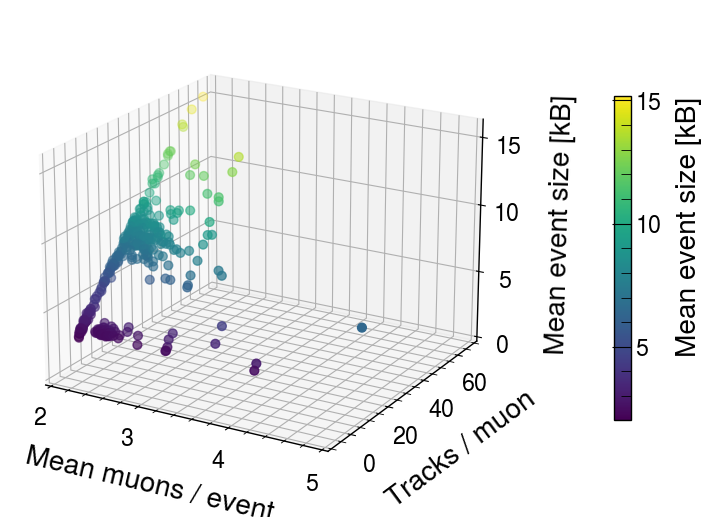

In [3]:
# mean event size in kB (compressed RAW size / number of events in that file)
mean_event_size = [
    (s / n / 1024) if (s is not None and n) else np.nan # divide by 1024 because we are dealing with bytes and we want kB
    for s, n in zip(comp_filesize, no_of_events)
]

x = np.array(mean_muon_mult)
y_tracks = np.array(mean_track_mult)
z = np.array(mean_event_size)

mask = ~(np.isnan(x) | np.isnan(y_tracks) | np.isnan(z) | (x == 0))
x, y_tracks, z = x[mask], y_tracks[mask], z[mask]

y = y_tracks / x   # tracks per muon

fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection="3d")

sc = ax.scatter(x, y, z, c=z, cmap="viridis", s=40)

ax.set_xlabel("Mean muons / event", labelpad=15)
ax.set_ylabel("Tracks / muon", labelpad=15)
ax.set_zlabel("Mean event size [kB]", labelpad=15)

ax.view_init(elev=20, azim=-60)  # adjust viewing angle so points don't overlap

cbar = fig.colorbar(sc, ax=ax, shrink=0.6, pad=0.15, label="Mean event size [kB]")

plt.show()

And now fit surface using SmoothBivariateSpline package.

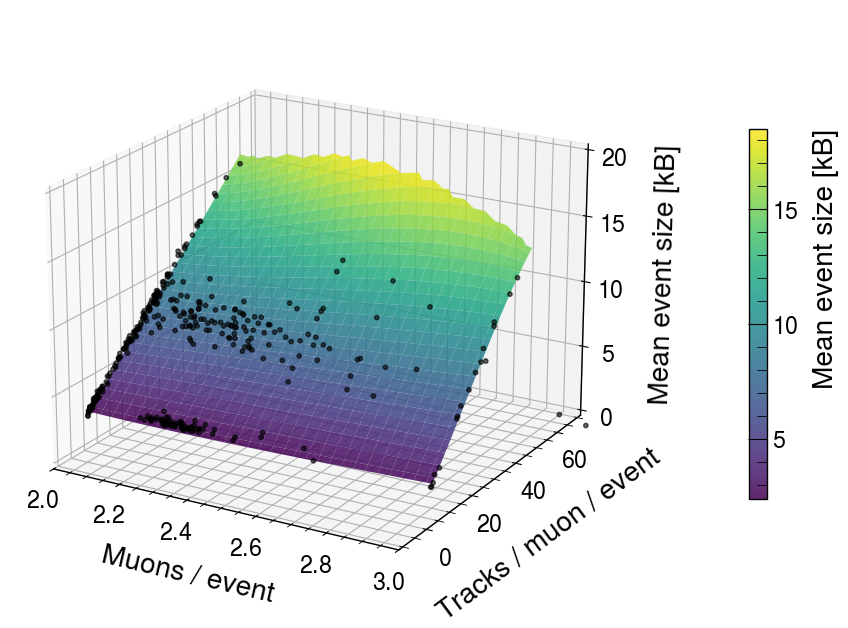

In [7]:
# need no_of_events masked the same way as x, y, z were
n_events = np.array(no_of_events)[mask]

weights = np.sqrt(n_events)

# fit a weighted smoothing spline surface; s controls smoothing strength
# (larger s = smoother/less overfit to noisy points; try a few values)
spline = SmoothBivariateSpline(x, y, z, w=weights, kx=3, ky=3, s=len(x) * 2)

grid_x, grid_y = np.meshgrid(
    np.linspace(x.min(), 3, 60),
    np.linspace(y.min(), y.max(), 60),
)

from scipy.spatial import Delaunay

points = np.column_stack([x, y])
hull = Delaunay(points)
inside = hull.find_simplex(np.column_stack([grid_x.ravel(), grid_y.ravel()])) >= 0

grid_z = spline.ev(grid_x.ravel(), grid_y.ravel())
grid_z[~inside] = np.nan
grid_z = grid_z.reshape(grid_x.shape)

fig = plt.figure(figsize=(11, 8))
ax = fig.add_subplot(111, projection="3d")
surf = ax.plot_surface(grid_x, grid_y, grid_z, cmap="viridis",
                        edgecolor='none', alpha=0.85)
ax.scatter(x, y, z, c='black', s=10, alpha=0.6)
ax.set_xlabel("Muons / event", labelpad=15)
ax.set_xlim(2,3)
ax.set_ylabel("Tracks / muon / event", labelpad=15)
ax.set_zlabel("Mean event size [kB]", labelpad=15)
ax.view_init(elev=20, azim=-60)
fig.colorbar(surf, ax=ax, shrink=0.6, pad=0.15, label="Mean event size [kB]")
plt.savefig("plots/extra_surface_visualisation.pdf")
plt.show()

While seeing a surface in 3D is very satisfying, it is more academically elegant to have a 2D plot with lines of equal size: the above plot is merely for visualisation purposes. At the end of this file, we have included the 2D plot with a couple of points to indicate where our Run-3 and Run-4 projections stand on this surface.

The next couple of cells tell us our tracks/muon multuplicity for PU 40-65 runs and PU 130-150 IN DATA, respectively. They show that the Run-3 tracker is unreliable at high-mu, where we get a plethora of artificial tracks.

Mean muon multiplicity = 2.257 +/- 0.008  (N = 6711)
Mean tracks/muon       = 3.659 +/- 0.028  (N = 6711)


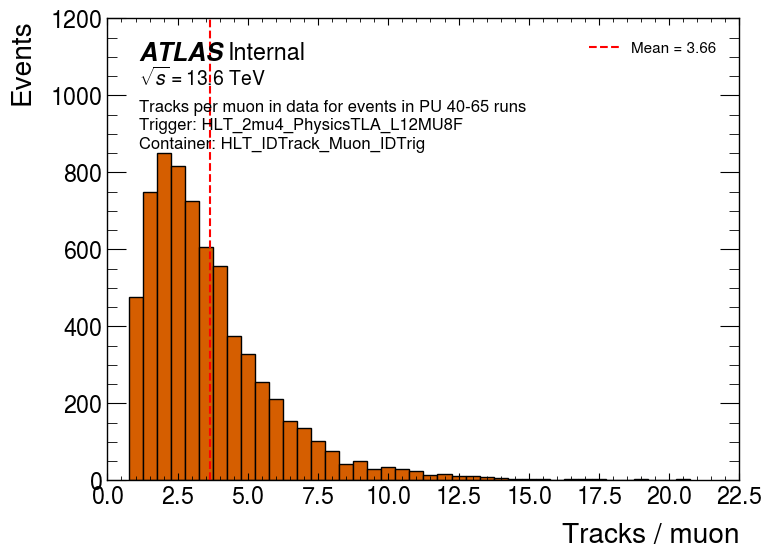

In [5]:
run_numbers = ["507671", "507733", "507758"] # THESE ARE THE RUN NUMBERS FOR THE PU 40-65 RUNS

csv_files = [
    f for f in glob.glob(f"{folder_csv}/*.csv")
    if any(f"data25_13p6TeV.00{run}." in f for run in run_numbers)
]

dfs = [pd.read_csv(f) for f in csv_files]
df = pd.concat(dfs, ignore_index=True)

track_container = "xAOD::TrackParticleContainer_v1#HLT_IDTrack_Muon_IDTrig"
muon_container = "xAOD::MuonContainer_v1#HLT_MuonsCB_RoI_TLA"

event_keys = ["run_number", "lb", "file", "event"]

track_mult = df[df["container"] == track_container].groupby(event_keys)["elements"].sum()
muon_mult = df[df["container"] == muon_container].groupby(event_keys)["elements"].sum()

# Generate statistics
combined = pd.concat([track_mult.rename("tracks"), muon_mult.rename("muons")], axis=1)
tracks_per_muon = combined["tracks"] / combined["muons"]
mean_tpm = tracks_per_muon.mean()

mean_muons = combined["muons"].mean()
sem_muons = combined["muons"].std(ddof=1) / np.sqrt(len(combined))
sem_tpm = tracks_per_muon.std(ddof=1) / np.sqrt(len(tracks_per_muon))

print(f"Mean muon multiplicity = {mean_muons:.3f} +/- {sem_muons:.3f}  (N = {len(combined)})")
print(f"Mean tracks/muon       = {mean_tpm:.3f} +/- {sem_tpm:.3f}  (N = {len(tracks_per_muon)})")

plt.figure(figsize=(8, 6))
plt.hist(tracks_per_muon, bins=40, edgecolor="black", align="left")
plt.axvline(mean_tpm, color="red", linestyle="--", linewidth=1.5,
            label=f"Mean = {mean_tpm:.2f}")
plt.xlabel("Tracks / muon")
plt.ylim(0, 1200)
plt.ylabel("Events")
plt.legend(loc="upper right", fontsize=11)

hep.atlas.label(label="Internal", data=True, year=2026, com=13.6)
plt.text(0.05, 0.825, 'Tracks per muon in data for events in PU 40-65 runs\nTrigger: HLT_2mu4_PhysicsTLA_L12MU8F\nContainer: HLT_IDTrack_Muon_IDTrig',
         transform=plt.gca().transAxes,
         verticalalignment='top', horizontalalignment='left',
         fontsize=12)

plt.savefig("plots/extra_tracks_pu40to65_data.pdf")
plt.show()

And now for high-mu, showing number of tracks blowing up.

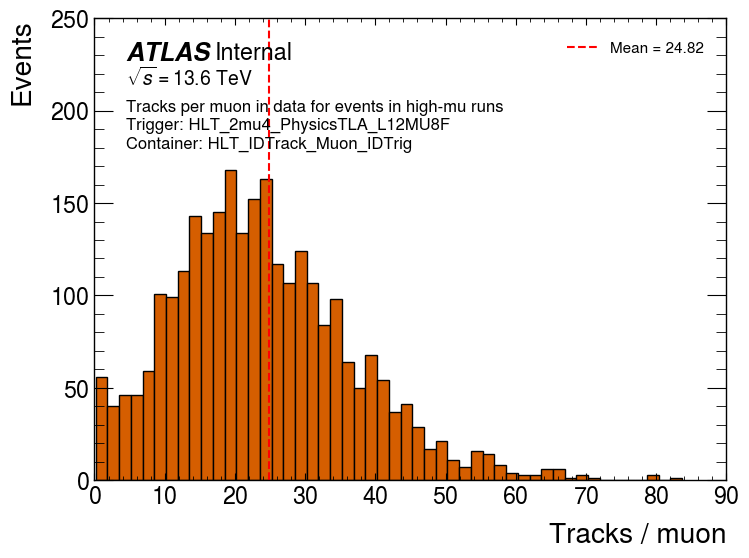

In [6]:
run_numbers = ["508073", "509891"] # THESE ARE HIGH-MU RUNS

csv_files = [
    f for f in glob.glob(f"{folder_csv}/*.csv")
    if any(f"data25_13p6TeV.00{run}." in f for run in run_numbers)
]

dfs = [pd.read_csv(f) for f in csv_files]
df = pd.concat(dfs, ignore_index=True)

track_container = "xAOD::TrackParticleContainer_v1#HLT_IDTrack_Muon_IDTrig"
muon_container = "xAOD::MuonContainer_v1#HLT_MuonsCB_RoI_TLA"

event_keys = ["run_number", "lb", "file", "event"]

track_mult = df[df["container"] == track_container].groupby(event_keys)["elements"].sum()
muon_mult = df[df["container"] == muon_container].groupby(event_keys)["elements"].sum()

combined = pd.concat([track_mult.rename("tracks"), muon_mult.rename("muons")], axis=1)
tracks_per_muon = combined["tracks"] / combined["muons"]

mean_tpm = tracks_per_muon.mean()

plt.figure(figsize=(8, 6))
plt.hist(tracks_per_muon, bins=50, edgecolor="black", align="left")
plt.axvline(mean_tpm, color="red", linestyle="--", linewidth=1.5,
            label=f"Mean = {mean_tpm:.2f}")
plt.xlabel("Tracks / muon")
plt.ylabel("Events")
plt.ylim(0, 250)
plt.legend(loc="upper right", fontsize=11)

hep.atlas.label(label="Internal", data=True, year=2026, com=13.6)
plt.text(0.05, 0.825, 'Tracks per muon in data for events in high-mu runs\nTrigger: HLT_2mu4_PhysicsTLA_L12MU8F\nContainer: HLT_IDTrack_Muon_IDTrig',
         transform=plt.gca().transAxes,
         verticalalignment='top', horizontalalignment='left',
         fontsize=12)

plt.savefig("plots/extra_tracks_high_mu_data.pdf")
plt.show()

Now that we've established that the Run-3 tracker is unreliable, let's use MC and the ITk to estimate our tracks/muon multiplicity for Run-4.

Mean = 5.139 +/- 0.146  (N_eff = 358.0, N_raw = 358)


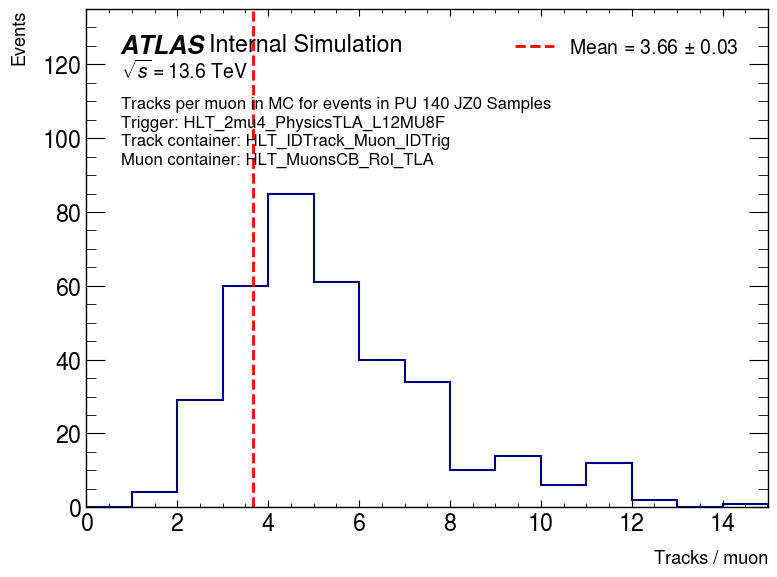

input_line_138:5:8: error: redefinition of 'deltaPhi'
double deltaPhi(double phi1, double phi2) {
       ^
input_line_60:5:8: note: previous definition is here
double deltaPhi(double phi1, double phi2) {
       ^
input_line_138:12:5: error: redefinition of 'countMatchedTracks'
int countMatchedTracks(
    ^
input_line_60:12:5: note: previous definition is here
int countMatchedTracks(
    ^


In [41]:
# This is some c++ code to do the dR matching: IF YOU MAKE CHANGES TO THIS YOU NEED TO RESTART THE KERNEL
ROOT.gInterpreter.Declare("""
#include <cmath>
#include "ROOT/RVec.hxx"

double deltaPhi(double phi1, double phi2) {
    double dphi = phi1 - phi2;
    while (dphi >  M_PI) dphi -= 2*M_PI;
    while (dphi < -M_PI) dphi += 2*M_PI;
    return dphi;
}

int countMatchedTracks(
    const ROOT::RVec<float>& muEta,
    const ROOT::RVec<float>& muPhi,
    const ROOT::RVec<float>& muAuthor,
    const ROOT::RVec<float>& muE,
    const ROOT::RVec<float>& trkEta,
    const ROOT::RVec<float>& trkPhi
) {
    std::vector<std::pair<double,double>> realMuons;
    for (size_t i = 0; i < muEta.size(); ++i) {
        if ((muAuthor[i] == 1 || muAuthor[i] == 6) && muE[i] > 4000) {
            realMuons.push_back({muEta[i], muPhi[i]});
        }
    }

    int nMatched = 0;
    for (size_t j = 0; j < trkEta.size(); ++j) {
        for (const auto& mu : realMuons) {
            double deta = trkEta[j] - mu.first;
            double dphi = deltaPhi(trkPhi[j], mu.second);
            double dR = std::sqrt(deta*deta + dphi*dphi);
            if (dR < 0.4) { nMatched++; break; }
        }
    }
    return nMatched;
}
""")

folder = "mc/user.ehossein.NGT2p7.mc21_14TeV.801165.Py8EG_jj_JZ0.deriv_JETM42.e8557_s4422_r17017_p7139.vPU140_emu_6_authored_EXT0"
files = sorted(glob.glob(f"{folder}/user.ehossein.*.root"))

df = ROOT.RDataFrame("TrigAna", files)

df = df.Define("isRealMuon", "HLT_MuonsCB_RoI_author == 1 || HLT_MuonsCB_RoI_author == 6")
df = df.Define("nMuons", "Sum(isRealMuon)")
df = df.Filter("emuTrigDec_EMULATION_EF_2xmu4_L0_2xMu8", "Emu trigger decision")
df = df.Filter(
    "Sum((HLT_MuonsCB_RoI_author == 1 && HLT_MuonsCB_RoI_E > 4000) || "
    "(HLT_MuonsCB_RoI_author == 6 && HLT_MuonsCB_RoI_E > 4000)) >= 2",
    "At least 2 real muons"
)

# dR-matched track count
df = df.Define(
    "nTracks",
    "countMatchedTracks(HLT_MuonsCB_RoI_Eta, HLT_MuonsCB_RoI_Phi, HLT_MuonsCB_RoI_author, "
    "HLT_MuonsCB_RoI_E, HLT_IDTrack_Muon_IDTrig_Eta, HLT_IDTrack_Muon_IDTrig_Phi)"
)
df = df.Define("nTracksPerMuon", "double(nTracks) / nMuons")

# Pull the same columns out of the RDataFrame and into pandas
cols = df.AsNumpy(["nTracksPerMuon", "EventInfo_mcEventWeight"])
data = pd.DataFrame({
    "nTracksPerMuon": cols["nTracksPerMuon"],
    "weight": cols["EventInfo_mcEventWeight"],
})

bins = np.arange(0, 16, 1)  # same as ROOT: 15 bins, width 1, 0 to 15
counts, edges = np.histogram(data["nTracksPerMuon"], bins=bins, weights=data["weight"])
mean_tpm_h = np.average(data["nTracksPerMuon"], weights=data["weight"])

weights = data["weight"].to_numpy()
values = data["nTracksPerMuon"].to_numpy()

# Weighted variance
variance_w = np.average((values - mean_tpm)**2, weights=weights)

# Weighted SEM (accounts for unequal weights via effective N)
sum_w = np.sum(weights)
sum_w2 = np.sum(weights**2)
n_eff = sum_w**2 / sum_w2 # effective number of entries
sem_tpm_h = np.sqrt(variance_w/n_eff)

print(f"Mean = {mean_tpm_h:.3f} +/- {sem_tpm_h:.3f}  (N_eff = {n_eff:.1f}, N_raw = {len(values)})")

fig, ax = plt.subplots(figsize=(8, 6))
ax.stairs(counts, edges, color="navy", linewidth=1.5)  # step outline, same look as ROOT's default draw
ax.axvline(mean_tpm, color="red", linestyle="--", linewidth=2,
           label=f"Mean = {mean_tpm:.2f} $\\pm$ {sem_tpm:.2f}")

hep.atlas.label(label="Internal Simulation", data=True, year=2026, com=13.6)
plt.text(0.05, 0.825, 'Tracks per muon in MC for events in PU 140 JZ0 Samples\nTrigger: HLT_2mu4_PhysicsTLA_L12MU8F\nTrack container: HLT_IDTrack_Muon_IDTrig\nMuon container: HLT_MuonsCB_RoI_TLA',
         transform=plt.gca().transAxes,
         verticalalignment='top', horizontalalignment='left',
         fontsize=12)


ax.set_xlabel("Tracks / muon", fontsize=13)
ax.set_ylabel("Events", fontsize=13)
ax.set_xlim(0, 15)
ax.set_ylim(0, 135)
ax.legend(loc="upper right", frameon=False)

plt.tight_layout()
plt.savefig("plots/1_tracks_per_muon_mc.pdf", dpi=150)
plt.show()

And now let's extrapolate muon multiplicity at PU 140 from data

[INFO] Found 373 CSV files
[INFO] 100/373 files
[INFO] 200/373 files
[INFO] 300/373 files
[INFO] 373/373 files
Fit params: [ 2.27492104e+00 -3.41204955e-04] +/- [0.03256601 0.00036035]
chi2 / ndof = 2.95 / 28 = 0.11
p-value = 1.000
Extrapolated mean muon multiplicity at mu=140: 2.227 +/- 0.027


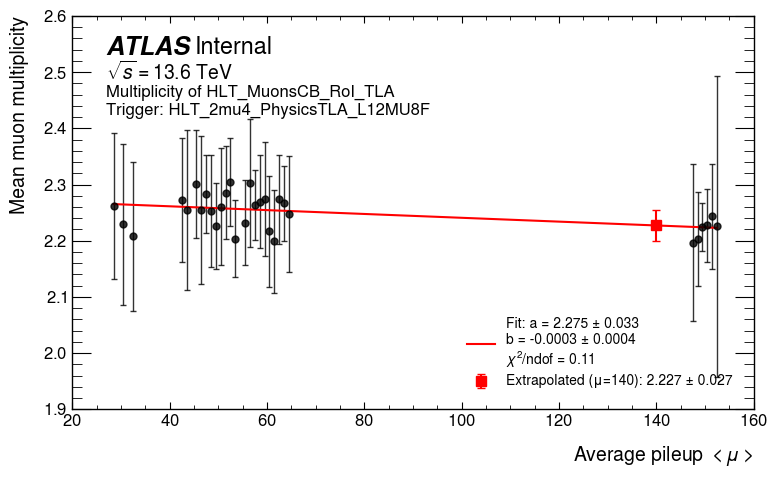

In [38]:
MUON_CONTAINER = "xAOD::MuonContainer_v1#HLT_MuonsCB_RoI_TLA"
JET_CONTAINER = "xAOD::JetContainer_v1#HLT_AntiKt4EMPFlowJets_subresjesgscIS_ftf_TLA"
MIN_MUONS = 2
MIN_JETS = 1
DATA_DIR = "data/csv"
CATEGORY_FILTER = None

csv_paths = []
for folder in sorted(glob.glob(os.path.join(DATA_DIR, "user.ehossein.CompressedRAW_and_ByContainer_EventSize.v8.muon_Trig_EXT1/"))):
    if CATEGORY_FILTER and CATEGORY_FILTER not in folder:
        continue
    csv_paths.extend(sorted(glob.glob(os.path.join(folder, "*.csv")))[:-1])
print(f"[INFO] Found {len(csv_paths)} CSV files")

# Accumulate totals per mu-bin (width 1) across all files, rather than
# a mean per file. muon_bins[mu_bin] = [sum_elements, n_qualifying_events]
muon_bins = defaultdict(lambda: [0, 0])
jet_bins = defaultdict(lambda: [0, 0])

for i, path in enumerate(csv_paths, 1):
    if i % 100 == 0 or i == len(csv_paths):
        print(f"[INFO] {i}/{len(csv_paths)} files")
    file_mu = None
    with open(path, newline="") as fh:
        for row in csv.DictReader(fh):
            if file_mu is None:
                file_mu = float(row["mu"])
                mu_bin = int(np.floor(file_mu))
            if row["container"] == MUON_CONTAINER:
                elements = int(row["elements"])
                if elements >= MIN_MUONS:
                    muon_bins[mu_bin][0] += elements
                    muon_bins[mu_bin][1] += 1
            elif row["container"] == JET_CONTAINER:
                elements = int(row["elements"])
                if elements >= MIN_JETS:
                    jet_bins[mu_bin][0] += elements
                    jet_bins[mu_bin][1] += 1

def bins_to_arrays(bins_dict, max_rel_err=0.15):
    mu_centers, means, yerrs = [], [], []
    for mu_bin in sorted(bins_dict):
        total_sum, total_n = bins_dict[mu_bin]
        if total_n == 0:
            continue  # leave empty bins out
        mean = total_sum / total_n
        yerr = np.sqrt(total_sum) / total_n
        if mean == 0 or (yerr / mean) > max_rel_err:
            continue  # drop points with >25% relative uncertainty
        mu_centers.append(mu_bin + 0.5)
        means.append(mean)
        yerrs.append(yerr)
    return np.array(mu_centers), np.array(means), np.array(yerrs)

muon_mus, muon_means, muon_yerr = bins_to_arrays(muon_bins)

from scipy.optimize import curve_fit
from scipy.stats import chi2 as chi2_dist

# --- choose your model ---
#def fit_func(x, a):          # constant fit
#    return a * np.ones_like(x)

def fit_func(x, a, b):     # linear fit alternative
    return a + b * x

p0 = [2.25, 0]                  # initial guess, adjust length to match fit_func params

popt, pcov = curve_fit(fit_func, muon_mus, muon_means, sigma=muon_yerr,
                        absolute_sigma=True, p0=p0)
perr = np.sqrt(np.diag(pcov))

residuals = muon_means - fit_func(muon_mus, *popt)
chi2_val = np.sum((residuals / muon_yerr) ** 2)
ndof = len(muon_mus) - len(popt)
chi2_ndof = chi2_val / ndof
p_value = 1 - chi2_dist.cdf(chi2_val, ndof)

print(f"Fit params: {popt} +/- {perr}")
print(f"chi2 / ndof = {chi2_val:.2f} / {ndof} = {chi2_ndof:.2f}")
print(f"p-value = {p_value:.3f}")

# --- plot ---
fig, ax = plt.subplots(figsize=(8, 5))
ax.errorbar(muon_mus, muon_means, yerr=muon_yerr, fmt="o", markersize=5,
            alpha=0.8, color="black", ecolor="black", elinewidth=1, capsize=2)

x_fit = np.linspace(muon_mus.min(), muon_mus.max(), 200)
ax.plot(x_fit, fit_func(x_fit, *popt), color="red", linewidth=1.5,
        label=(f"Fit: a = {popt[0]:.3f} ± {perr[0]:.3f}\n"
               f"b = {popt[1]:.4f} ± {perr[1]:.4f}\n"
               f"$\\chi^2$/ndof = {chi2_ndof:.2f}"))

ax.set_xlabel(r"Average pileup $<\mu>$", fontsize=14)
ax.set_ylabel("Mean muon multiplicity", fontsize=14)
ax.tick_params(axis="both", labelsize=12)
ax.legend(loc="lower right", fontsize=11)

hep.atlas.label(label="Internal", data=True, year=2026, com=13.6, ax=ax)
ax.text(0.05, 0.825, "Multiplicity of HLT_MuonsCB_RoI_TLA\nTrigger: HLT_2mu4_PhysicsTLA_L12MU8F",
        transform=ax.transAxes,
        verticalalignment="top", horizontalalignment="left",
        fontsize=12)

x0 = 140.0

y0 = fit_func(x0, *popt)

# propagate uncertainty using the full covariance matrix:
# y = a + b*x  ->  dy/da = 1, dy/db = x
grad = np.array([1.0, x0])
y0_var = grad @ pcov @ grad
y0_err = np.sqrt(y0_var)

print(f"Extrapolated mean muon multiplicity at mu=140: {y0:.3f} +/- {y0_err:.3f}")

# add it to the plot
ax.errorbar([x0], [y0], yerr=[y0_err], fmt="s", markersize=7,
            color="red", ecolor="red", elinewidth=1.5, capsize=3,
            label=f"Extrapolated (μ=140): {y0:.3f} ± {y0_err:.3f}")
ax.legend(loc="lower right", fontsize=10)

plt.tight_layout()
plt.savefig("plots/2_muon_multiplicity_vs_pileup_fit.pdf", dpi=150)

And so knowing our muon and tracks/muon multiplicity at PU 140, we can map where we will be in terms of event size in Run-4.

Event size = 3.05 +/- 0.04 kB
  dz/dx = 0.32 kB per unit muons/event
  dz/dy = 0.26 kB per unit tracks/muon
Run-3 Event size = 2.66 +/- 0.01 kB
  dz/dx = 0.22 kB per unit muons/event
  dz/dy = 0.27 kB per unit tracks/muon


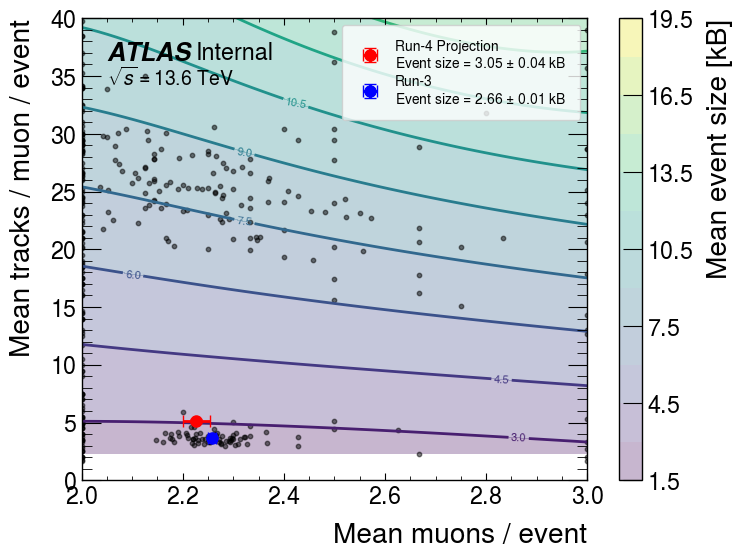

In [37]:
fig2, ax2 = plt.subplots(figsize=(8, 6))

# Run-4 point
run4_x, run4_xerr = y0, y0_err   # mean muons/event
run4_y, run4_yerr = mean_tpm_h, sem_tpm_h   # mean tracks/muon/event

# Run-3 point
run3_x, run3_xerr = mean_muons, sem_muons
run3_y, run3_yerr = mean_tpm, sem_tpm

# Interpolate the event size at this (x, y) from your existing grid
run4_z = griddata(
    (grid_x.ravel(), grid_y.ravel()), grid_z.ravel(),
    (run4_x, run4_y), method="linear"
)
run4_z = float(run4_z)

# Finite-difference step (small relative to grid spacing)
h_x = 0.01
h_y = 0.1

def z_at(x, y):
    val = griddata(
        (grid_x.ravel(), grid_y.ravel()), grid_z.ravel(),
        (x, y), method="linear"
    )
    return float(val)

# Central-difference partial derivatives at the Run-4 point
dz_dx = (z_at(run4_x + h_x, run4_y) - z_at(run4_x - h_x, run4_y)) / (2 * h_x)
dz_dy = (z_at(run4_x, run4_y + h_y) - z_at(run4_x, run4_y - h_y)) / (2 * h_y)

# Propagate (assuming x, y uncorrelated)
run4_zerr = np.sqrt((dz_dx * run4_xerr)**2 + (dz_dy * run4_yerr)**2)

print(f"Event size = {run4_z:.2f} +/- {run4_zerr:.2f} kB")
print(f"  dz/dx = {dz_dx:.2f} kB per unit muons/event")
print(f"  dz/dy = {dz_dy:.2f} kB per unit tracks/muon")

# Interpolate the event size at the Run-3 point
run3_z = z_at(run3_x, run3_y)

# Central-difference partial derivatives at the Run-3 point
dz_dx_r3 = (z_at(run3_x + h_x, run3_y) - z_at(run3_x - h_x, run3_y)) / (2 * h_x)
dz_dy_r3 = (z_at(run3_x, run3_y + h_y) - z_at(run3_x, run3_y - h_y)) / (2 * h_y)

# Propagate (assuming x, y uncorrelated)
run3_zerr = np.sqrt((dz_dx_r3 * run3_xerr)**2 + (dz_dy_r3 * run3_yerr)**2)

print(f"Run-3 Event size = {run3_z:.2f} +/- {run3_zerr:.2f} kB")
print(f"  dz/dx = {dz_dx_r3:.2f} kB per unit muons/event")
print(f"  dz/dy = {dz_dy_r3:.2f} kB per unit tracks/muon")

# Plot the point with error bars
ax2.errorbar(
    run4_x, run4_y, xerr=run4_xerr, yerr=run4_yerr,
    fmt="o", color="red", markersize=8, capsize=4, zorder=5,
    label=f"Run-4 Projection\nEvent size = {run4_z:.2f} $\\pm$ {run4_zerr:.2f} kB"
)

ax2.errorbar(
    run3_x, run3_y, xerr=run3_xerr, yerr=run3_yerr,
    fmt="o", color="blue", markersize=8, capsize=4, zorder=5,
    label=f"Run-3\nEvent size = {run3_z:.2f} $\\pm$ {run3_zerr:.2f} kB"
)

ax2.legend(loc="upper right", frameon=True, fontsize=10)

cont = ax2.contour(grid_x, grid_y, grid_z, levels=12, cmap="viridis")
ax2.clabel(cont, inline=True, fontsize=8, fmt="%.1f")

# Fill background
cf = ax2.contourf(grid_x, grid_y, grid_z, levels=15, cmap="viridis", alpha=0.3)
fig2.colorbar(cf, ax=ax2, label="Mean event size [kB]")
hep.atlas.label(label="Internal", data=True, year=2026, com=13.6)
ax2.scatter(x, y, c='black', s=10, alpha=0.5)
ax2.set_xlabel("Mean muons / event")
ax2.set_xlim(2, 3)
ax2.set_ylim(0, 40)
ax2.set_ylabel("Mean tracks / muon / event")
plt.savefig("plots/3_mapped_event_size.pdf")
plt.show()